# MRT stoppages seen in Taipei MRT ridership and YouBike rentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunglinn/youbike-analysis/blob/main/notebooks/mrt_youbike_disruption.ipynb)

This notebook estimates when the Taipei MRT stopped during an event (here, two earthquakes) and checks whether YouBike rentals picked up the stranded riders.

1. Download the hourly MRT station counts and the YouBike 2.0 rental records for the months needed.
2. Compare each hour of the event day with the same hour on normal baseline days.
3. Estimate how long the MRT stopped, and check whether the drop was network-wide or one line.
4. Compare YouBike rentals with the same baseline, including trips between MRT stations.

**Data sources**
- MRT: Taipei Metro hourly station-to-station counts, [臺北捷運各站分時進出量統計](https://data.taipei/dataset/detail?id=63f31c7e-7fc3-418b-bd82-b95158755b4d) (2017 on). The older [data.gov.tw dataset 128683](https://data.gov.tw/en/datasets/128683) stops at Dec 2016 and points to this one.
- YouBike: Taipei YouBike 2.0 monthly rental records (臺北市 YouBike2.0 票證刷卡資料).

Both sources record time **by the hour only**, so every estimate below is at hourly resolution.

In [1]:
%pip install -q duckdb pyarrow pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Pick the event

Each event lists the day to test and the baseline days to compare it with. Use the same weekday, and skip days with abnormal numbers (holidays, heavy rain). Section 2 prints daily totals so you can check the baseline.

In [2]:
EVENTS = {
    "hualien_2024": dict(
        label="Hualien M7.2 earthquake", date="2024-04-03", event_time="07:58",
        # three Wednesdays before the quake; Mar 6 skipped (YouBike rentals about half of normal)
        baseline=["2024-03-13", "2024-03-20", "2024-03-27"],
        hours=list(range(6, 14)),
    ),
    "yilan_2021": dict(
        label="Yilan M6.5 earthquake", date="2021-10-24", event_time="13:11",
        # the other Sundays in October 2021
        baseline=["2021-10-03", "2021-10-10", "2021-10-17", "2021-10-31"],
        hours=list(range(10, 18)),
    ),
}
EVENT = "hualien_2024"  # <- change this to switch events

ev = EVENTS[EVENT]
print(ev["label"], ev["date"], "| baseline:", ", ".join(ev["baseline"]))

Hualien M7.2 earthquake 2024-04-03 | baseline: 2024-03-13, 2024-03-20, 2024-03-27


## 2. Download the data

Files are cached, so re-running is fast. Each MRT month is a ~300 MB CSV, which gets reduced to hourly entries per station and then deleted. Each YouBike month is a 20–130 MB zip, reduced to hourly counts per station pair.

In [3]:
import csv, io, ssl, urllib.request, urllib.parse, zipfile
from pathlib import Path
import duckdb, pandas as pd

DATA = Path("../data/cache") if Path("../data").is_dir() else Path("data_cache")
DATA.mkdir(parents=True, exist_ok=True)

MRT_INDEX = ("https://data.taipei/api/dataset/63f31c7e-7fc3-418b-bd82-b95158755b4d/"
             "resource/eb481f58-1238-4cff-8caa-fa7bb20cb4f4/download")
YB_URL = ("https://tcgbusfs.blob.core.windows.net/dotapp/youbike_second_ticket_opendata/"
          "{y}/{y}-{m:02d}/" + urllib.parse.quote("{y}{m:02d}_YouBike2.0票證刷卡資料.zip", safe="{}:_"))

# data.taipei's certificate lacks a Subject Key Identifier, which Python 3.13+ rejects under its
# stricter default checks; keep normal certificate verification but drop that one strict flag.
SSL_CTX = ssl.create_default_context()
SSL_CTX.verify_flags &= ~getattr(ssl, "VERIFY_X509_STRICT", 0)

def urlopen(url, timeout=120):
    req = urllib.request.Request(url, headers={"User-Agent": "youbike-analysis-notebook"})
    return urllib.request.urlopen(req, timeout=timeout, context=SSL_CTX)

def fetch(url, dest):
    with urlopen(url) as r, open(dest, "wb") as f:
        while chunk := r.read(1 << 20):
            f.write(chunk)

_mrt_index = None
def mrt_month(y, m):
    """Hourly entries per station: columns d, h, o (entry station), n."""
    global _mrt_index
    out = DATA / f"mrt_entries_{y}{m:02d}.parquet"
    if out.exists():
        return out
    if _mrt_index is None:
        with urlopen(MRT_INDEX) as r:
            _mrt_index = list(csv.reader(io.StringIO(r.read().decode("utf-8-sig"))))
    url = next(r[-1] for r in _mrt_index if r[1:3] == [str(y), str(m)])
    tmp = DATA / f"mrt_{y}{m:02d}.csv"
    print("downloading MRT", y, m); fetch(url, tmp)
    # columns: date, hour, entry station, exit station, riders (by position, header is Chinese)
    duckdb.sql(f"""copy (select #1::date d, #2::int h, #3 o, sum(#5::int) n
                 from read_csv('{tmp}', all_varchar=true) group by all) to '{out}'""")
    tmp.unlink()
    return out

def youbike_month(y, m):
    """Hourly rentals per station pair: columns d, h, rent_station, return_station, n."""
    out = DATA / f"youbike_{y}{m:02d}.parquet"
    if out.exists():
        return out
    zp, tmp = DATA / f"yb_{y}{m:02d}.zip", DATA / f"yb_{y}{m:02d}.csv"
    print("downloading YouBike", y, m); fetch(YB_URL.format(y=y, m=m), zp)
    with zipfile.ZipFile(zp) as z, z.open(z.infolist()[0]) as src, open(tmp, "wb") as dst:
        while chunk := src.read(1 << 20):
            dst.write(chunk)
    zp.unlink()
    # some months ship without a header row, so read by position and drop a header if present;
    # strict_mode=false copes with files whose header ends in CRLF but rows end in LF (e.g. 2021-10)
    has_header = tmp.open(encoding="utf-8", errors="replace").readline().startswith("rent_time")
    duckdb.sql(f"""copy (select cast(#1 as timestamp)::date d, hour(cast(#1 as timestamp)) h,
                   #2 rent_station, #4 return_station, count(*) n
                 from read_csv('{tmp}', delim=',', header={str(has_header).lower()},
                               all_varchar=true, ignore_errors=true, strict_mode=false)
                 group by all) to '{out}'""")
    tmp.unlink()
    return out

days = [ev["date"], *ev["baseline"]]
months = sorted({(int(d[:4]), int(d[5:7])) for d in days})
mrt_files = [str(mrt_month(y, m)) for y, m in months]
yb_files = [str(youbike_month(y, m)) for y, m in months]

con = duckdb.connect()
con.sql(f"create or replace view mrt as select * from read_parquet({mrt_files})")
con.sql(f"create or replace view yb as select * from read_parquet({yb_files})")
day_list = ", ".join(f"date '{d}'" for d in days)
con.sql(f"""
  select d, dayname(d) weekday, m.n mrt_entries, y.n youbike_rentals,
         case when d = date '{ev["date"]}' then 'event' else 'baseline' end day_type
  from (select d, sum(n) n from mrt group by d) m join (select d, sum(n) n from yb group by d) y using (d)
  where d in ({day_list}) order by d""").df()

,d,weekday,mrt_entries,youbike_rentals,day_type
0,2024-03-13,Wednesday,2242244.0,131955.0,baseline
1,2024-03-20,Wednesday,2239623.0,133936.0,baseline
2,2024-03-27,Wednesday,2240851.0,140088.0,baseline
3,2024-04-03,Wednesday,1895368.0,141953.0,event


## 3. Hourly comparison with the baseline

For each hour: `normal` is the mean of the baseline days, and `pct` is the event day as a share of normal.

In [4]:
def hourly(view):
    return con.sql(f"""
      with t as (select d, h, sum(n) n from {view} where d in ({day_list}) group by all)
      select h,
             avg(n) filter (where d <> date '{ev["date"]}') "normal",
             sum(n) filter (where d = date '{ev["date"]}') "event"
      from t group by h order by h""").df().set_index("h")

hr = hourly("mrt").join(hourly("yb"), lsuffix="_mrt", rsuffix="_yb").loc[ev["hours"]]
hr["pct_mrt"] = hr.event_mrt / hr.normal_mrt
hr["pct_yb"] = hr.event_yb / hr.normal_yb
hr.style.format({c: "{:,.0f}" for c in ["normal_mrt", "event_mrt", "normal_yb", "event_yb"]}
                | {"pct_mrt": "{:.0%}", "pct_yb": "{:.0%}"})

,normal_mrt,event_mrt,normal_yb,event_yb,pct_mrt,pct_yb
h,,,,,,
6,"31,457","31,599","2,875","3,297",100%,115%
7,"151,198","142,643","8,457","8,748",94%,103%
8,"270,466","78,189","10,359","12,376",29%,119%
9,"150,351","124,823","7,222","8,341",83%,115%
10,"92,570","88,650","5,747","5,313",96%,92%
11,"85,373","77,582","6,312","6,276",91%,99%
12,"94,694","83,746","8,280","8,303",88%,100%
13,"97,286","90,726","7,235","7,317",93%,101%


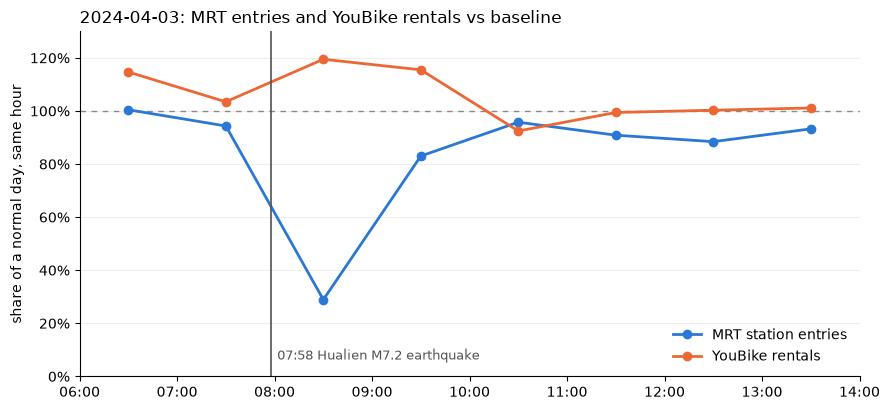

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.2))
x = [h + 0.5 for h in hr.index]  # plot each hour at its midpoint
ax.axhline(1, color="#8a8983", lw=1, ls=(0, (4, 4)))
ax.plot(x, hr.pct_mrt, "-o", color="#2a78d6", lw=2, ms=6, label="MRT station entries")
ax.plot(x, hr.pct_yb, "-o", color="#eb6834", lw=2, ms=6, label="YouBike rentals")
eh, em = map(int, ev["event_time"].split(":"))
ax.axvline(eh + em / 60, color="#52514e", lw=1.2)
ax.text(eh + em / 60 + 0.06, 0.04, f'{ev["event_time"]} {ev["label"]}', transform=ax.get_xaxis_transform(),
        ha="left", va="bottom", fontsize=9, color="#52514e")
ax.set_xticks(range(hr.index.min(), hr.index.max() + 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(hr.index.min(), hr.index.max() + 2)])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylim(0, max(1.3, hr[["pct_mrt", "pct_yb"]].max().max() + 0.1))
ax.set_ylabel("share of a normal day, same hour")
ax.set_title(f'{ev["date"]}: MRT entries and YouBike rentals vs baseline', loc="left")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#efeee9")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 4. How long did the MRT stop?

This takes the worst MRT hour and turns its missing entries into minutes, assuming nobody entered during the stop. Station gates usually stay open during a halt, so treat the result as a **lower bound**.

In [6]:
worst = hr.pct_mrt.idxmin()
missing = hr.normal_mrt[worst] - hr.event_mrt[worst]
print(f"Worst hour: {worst:02d}:00-{worst+1:02d}:00 at {hr.pct_mrt[worst]:.0%} of normal")
print(f"Missing entries: {missing:,.0f} of {hr.normal_mrt[worst]:,.0f} expected")
print(f"Equivalent full stop: ~{missing / hr.normal_mrt[worst] * 60:.0f} minutes")

Worst hour: 08:00-09:00 at 29% of normal
Missing entries: 192,277 of 270,466 expected
Equivalent full stop: ~43 minutes


## 5. Network-wide or one line?

Per-line entries in the worst hour. Transfer stations are left out, because their entries can't be split by line. If every line drops together, it's a deliberate network-wide halt; if one line drops alone, it's a line fault.

In [7]:
LINES = {
    "Brown (BR)": "動物園 木柵 萬芳社區 萬芳醫院 辛亥 麟光 六張犁 科技大樓 中山國中 松山機場 大直 劍南路 西湖 港墘 文德 內湖 大湖公園 葫洲 東湖 南港軟體園區",
    "Red (R)": "象山 台北101/世貿 信義安和 大安森林公園 台大醫院 雙連 圓山 劍潭 士林 芝山 明德 石牌 唭哩岸 奇岩 北投 新北投 復興崗 忠義 關渡 竹圍 紅樹林 淡水",
    "Green (G)": "松山 南京三民 台北小巨蛋 小南門 台電大樓 公館 萬隆 景美 七張 新店區公所 新店 小碧潭",
    "Orange (O)": "南勢角 永安市場 頂溪 行天宮 中山國小 大橋頭站 台北橋 菜寮 先嗇宮 新莊 輔大 丹鳳 迴龍 三重國小 三和國中 徐匯中學 三民高中 蘆洲",
    "Blue (BL)": "頂埔 永寧 土城 海山 亞東醫院 府中 江子翠 龍山寺 善導寺 忠孝敦化 國父紀念館 市政府 永春 後山埤 昆陽",
    "Circular (Y)": "十四張 秀朗橋 景平 中和 橋和 中原 板新 Y板橋 幸福 新北產業園區",
}
line_of = pd.DataFrame([(s, k) for k, v in LINES.items() for s in v.split()], columns=["o", "line"])
con.register("line_of", line_of)

st = con.sql(f"""
  with t as (select o, d, sum(n) n from mrt where d in ({day_list}) and h = {worst} group by all)
  select o, avg(n) filter (where d <> date '{ev["date"]}') "normal", sum(n) filter (where d = date '{ev["date"]}') "event"
  from t group by o""").df()
st["pct"] = st.event / st.normal
busy = st[st.normal > 200]
print(f"{(busy.pct < 0.75).sum()} of {len(busy)} busy stations (>200 entries normally) fell below 75% of normal; "
      f"median station {busy.pct.median():.0%}")
by_line = st.merge(line_of, on="o").groupby("line")[["normal", "event"]].sum()
by_line["pct"] = by_line.event / by_line.normal
by_line.sort_values("pct").style.format({"normal": "{:,.0f}", "event": "{:,.0f}", "pct": "{:.0%}"})

114 of 114 busy stations (>200 entries normally) fell below 75% of normal; median station 27%


,normal,event,pct
line,,,
Circular (Y),"3,069",438,14%
Orange (O),"57,699","13,882",24%
Green (G),"24,592","6,305",26%
Red (R),"41,611","10,989",26%
Brown (BR),"25,474","7,709",30%
Blue (BL),"45,688","17,509",38%


## 6. Did YouBike pick up stranded MRT riders?

Total rentals are noisy, because weather swings them a lot. The mix of trips is more telling. If MRT riders switched to bikes, a bigger share of rentals should start at bike stations named after an MRT exit (`捷運…站`), and more trips should run from one MRT station to another.

In [8]:
yb_mix = con.sql(f"""
  select d, h, sum(n) rentals,
         sum(n) filter (where rent_station like '捷運%') from_mrt,
         sum(n) filter (where rent_station like '捷運%' and return_station like '捷運%'
                        and rent_station <> return_station) mrt_to_mrt
  from yb where d in ({day_list}) and h in ({", ".join(map(str, ev["hours"]))}) group by all""").df()
yb_mix["role"] = (yb_mix.d.astype(str) == ev["date"]).map({True: "event", False: "baseline"})
mix = yb_mix.groupby(["h", "role"])[["rentals", "from_mrt", "mrt_to_mrt"]].sum().unstack("role")
out = pd.DataFrame({
    "from_mrt_baseline": mix.from_mrt.baseline / mix.rentals.baseline,
    "from_mrt_event": mix.from_mrt.event / mix.rentals.event,
    "mrt_to_mrt_baseline": mix.mrt_to_mrt.baseline / mix.rentals.baseline,
    "mrt_to_mrt_event": mix.mrt_to_mrt.event / mix.rentals.event,
})
excess = hr.event_yb - hr.normal_yb
print(f"YouBike rentals in the worst MRT hour: {hr.pct_yb[worst]:.0%} of normal ({excess[worst]:+,.0f} rentals)")
out.style.format("{:.1%}")

YouBike rentals in the worst MRT hour: 119% of normal (+2,017 rentals)


,from_mrt_baseline,from_mrt_event,mrt_to_mrt_baseline,mrt_to_mrt_event
h,,,,
6,19.5%,20.0%,2.2%,2.3%
7,21.9%,22.1%,2.2%,2.3%
8,23.2%,26.1%,2.3%,7.5%
9,21.3%,23.4%,2.4%,4.2%
10,20.9%,21.8%,2.8%,3.1%
11,20.5%,20.4%,3.3%,3.1%
12,21.4%,20.3%,3.3%,2.6%
13,23.4%,23.2%,3.4%,3.1%


## Caveats

- **Hourly data:** both datasets only give the hour, so a stop is spread across the hours it touches and its start and end times can't be read off directly. Event times (the 07:58 and 13:11 quakes) come from outside the data.
- **The baseline matters:** check the daily totals in section 2. Holidays and rainy days distort the "normal" level, especially for YouBike.
- **Station matching:** "MRT station" in section 6 means bike stations named after an MRT exit. Bike stations near an exit but named differently are missed.
- **Per-line check:** transfer stations are left out of section 5, so the line totals cover only non-transfer stations.